In [1]:
import platform
import sklearn

print(platform.system())
if platform.system()== 'Windows':
    sklearn.set_config(display='text')

Windows


In [2]:
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

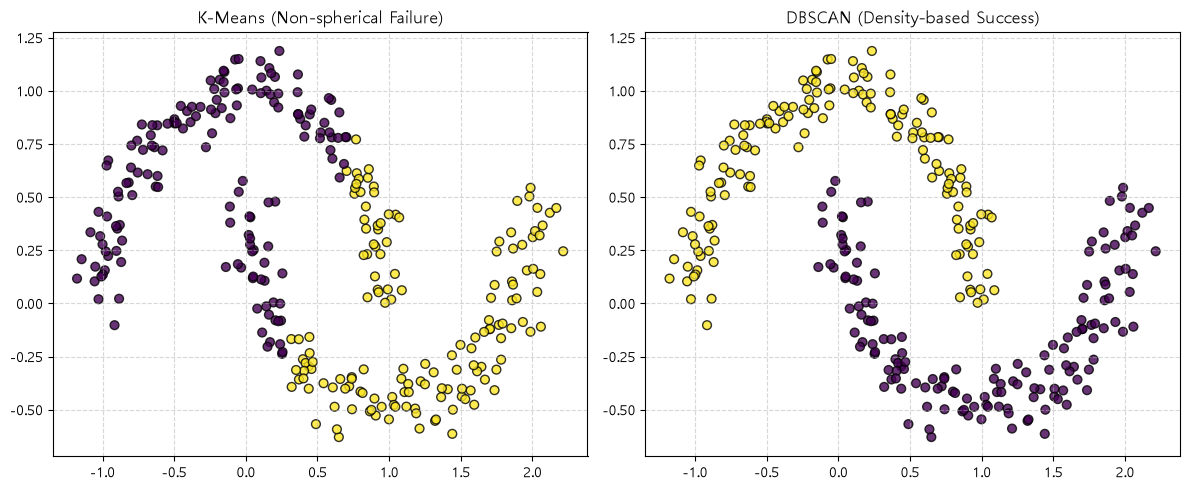

--- DBSCAN 군집화 요약 ---
추출된 군집 개수 : 2개
감지된 이상치(노이즈) 개수 : 0개


In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons

# 1. 초승달 모양 데이터셋 생성 (노이즈 추가)
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)

# 2. DBSCAN 및 K-Means 모델 생성 및 학습
# DBSCAN: 반경(eps)=0.2, 최소 이웃 수(min_samples)=5
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# 비교용 K-Means (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# 3. 시각화 (K-Means vs DBSCAN)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) K-Means 군집화 결과
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=40,
    edgecolors="k",
    alpha=0.8,
)
axes[0].set_title("K-Means (Non-spherical Failure)", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) DBSCAN 군집화 결과
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=40,
    edgecolors="k",
    alpha=0.8,
)
axes[1].set_title("DBSCAN (Density-based Success)", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 4. DBSCAN 결과 출력
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"--- DBSCAN 군집화 요약 ---")
print(f"추출된 군집 개수 : {n_clusters}개")
print(f"감지된 이상치(노이즈) 개수 : {n_noise}개")

=== 군집화 평가 결과 비교 ===
DBSCAN  -> ARI (정답 일치도): 1.0000 | Silhouette Score: 0.3803
K-Means -> ARI (정답 일치도): 0.4790 | Silhouette Score: 0.4936
-------------------------------------------------------
DBSCAN 형성된 군집 수 : 2개
DBSCAN 감지된 노이즈 개수: 0개


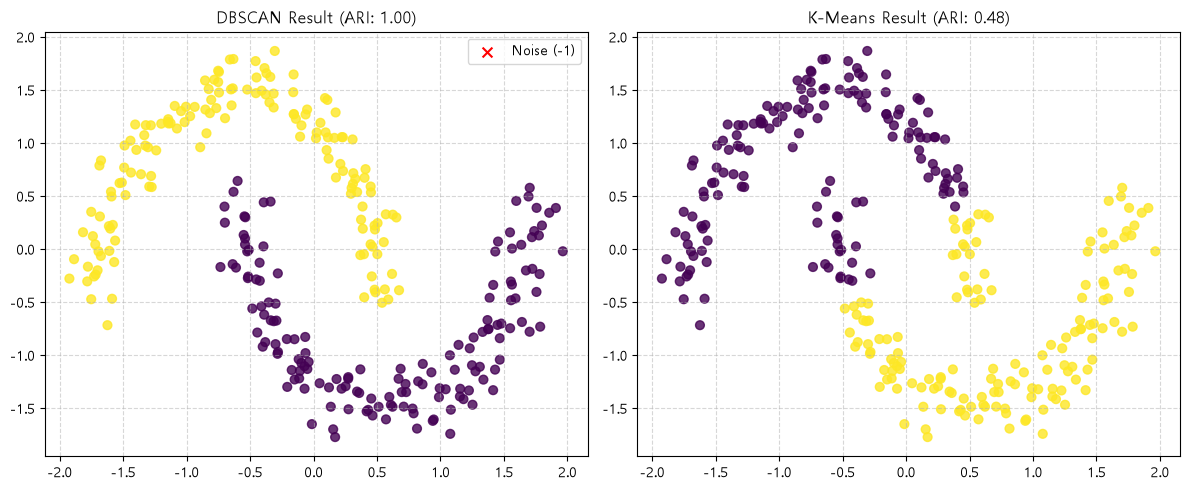

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. 초승달 모양(make_moons) 비구형 데이터 생성
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

# 2. 데이터 전처리 (StandardScaler)
# 밀도/거리 기반 알고리즘이므로 스케일링을 반드시 진행합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 모델 생성 및 학습
# DBSCAN (eps: 탐색 반경, min_samples: 최소 이웃 수)
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# K-Means (비교용)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# ==================================================
# 4. 군집화 평가 (Evaluation)
# ==================================================
# (1) ARI (Adjusted Rand Index): 실제 정답 라벨과 얼마나 일치하는지 평가 (1에 가까울수록 완벽)
ari_db = adjusted_rand_score(y_true, db_labels)
ari_km = adjusted_rand_score(y_true, km_labels)

# (2) Silhouette Score: 노이즈(-1) 포인트를 제외한 순수 군집 데이터로 계산
mask = db_labels != -1
sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
sil_km = silhouette_score(X_scaled, km_labels)

print("=== 군집화 평가 결과 비교 ===")
print(
    f"DBSCAN  -> ARI (정답 일치도): {ari_db:.4f} | Silhouette Score:"
    f" {sil_db:.4f}"
)
print(
    f"K-Means -> ARI (정답 일치도): {ari_km:.4f} | Silhouette Score:"
    f" {sil_km:.4f}"
)
print("-" * 55)
print(
    f"DBSCAN 형성된 군집 수 : {len(set(db_labels)) - (1 if -1 in db_labels else 0)}개"
)
print(f"DBSCAN 감지된 노이즈 개수: {list(db_labels).count(-1)}개")

# ==================================================
# 5. 결과 시각화 비교
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) DBSCAN 결과 시각화
axes[0].scatter(
    X_scaled[db_labels != -1, 0],
    X_scaled[db_labels != -1, 1],
    c=db_labels[db_labels != -1],
    cmap="viridis",
    s=40,
    alpha=0.8,
)
axes[0].scatter(
    X_scaled[db_labels == -1, 0],
    X_scaled[db_labels == -1, 1],
    c="red",
    marker="x",
    s=50,
    label="Noise (-1)",
)
axes[0].set_title(f"DBSCAN Result (ARI: {ari_db:.2f})")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) K-Means 결과 시각화
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=km_labels,
    cmap="viridis",
    s=40,
    alpha=0.8,
)
axes[1].set_title(f"K-Means Result (ARI: {ari_km:.2f})")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()